In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 6)
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
import numpy as np 
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False  # 允许负号显示

In [60]:
test_data = pd.read_csv('test.csv')
train_data = pd.read_csv('train.csv')
train_data.head()

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP


In [61]:
test_data = test_data.drop(columns=['id'])
train_data = train_data.drop(columns=['id'])

In [62]:
print(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Temparature      750000 non-null  int64 
 1   Humidity         750000 non-null  int64 
 2   Moisture         750000 non-null  int64 
 3   Soil Type        750000 non-null  object
 4   Crop Type        750000 non-null  object
 5   Nitrogen         750000 non-null  int64 
 6   Potassium        750000 non-null  int64 
 7   Phosphorous      750000 non-null  int64 
 8   Fertilizer Name  750000 non-null  object
dtypes: int64(6), object(3)
memory usage: 51.5+ MB
None


In [63]:
num_col = [i for i in train_data.columns if train_data[i].dtype == 'int64']
cat_col = [i for i in train_data.columns if  i not in num_col]
print(f'数值变量有{len(num_col)}个, 分类变量有{len(cat_col)}个')

数值变量有6个, 分类变量有3个


# EDA

In [64]:
# fig, axes = plt.subplots(len(num_col), 2, figsize=(18, 35))
# for i, col in enumerate(num_col):
#     sns.histplot(train_data[col], kde=True, ax=axes[i, 0], color='skyblue')
#     axes[i, 0].set_title(f'{col}分布图', fontsize=22)
#     axes[i, 0].grid(True, linestyle='--', alpha=0.7)
#     
#     sns.boxenplot(train_data[col], ax=axes[i, 1], color='lightgreen')
#     axes[i, 1].set_title(f'{col}箱线图', fontsize=22)
#     axes[i, 1].grid(True, linestyle='--', alpha=0.7)
#     
# plt.tight_layout()
# plt.show()

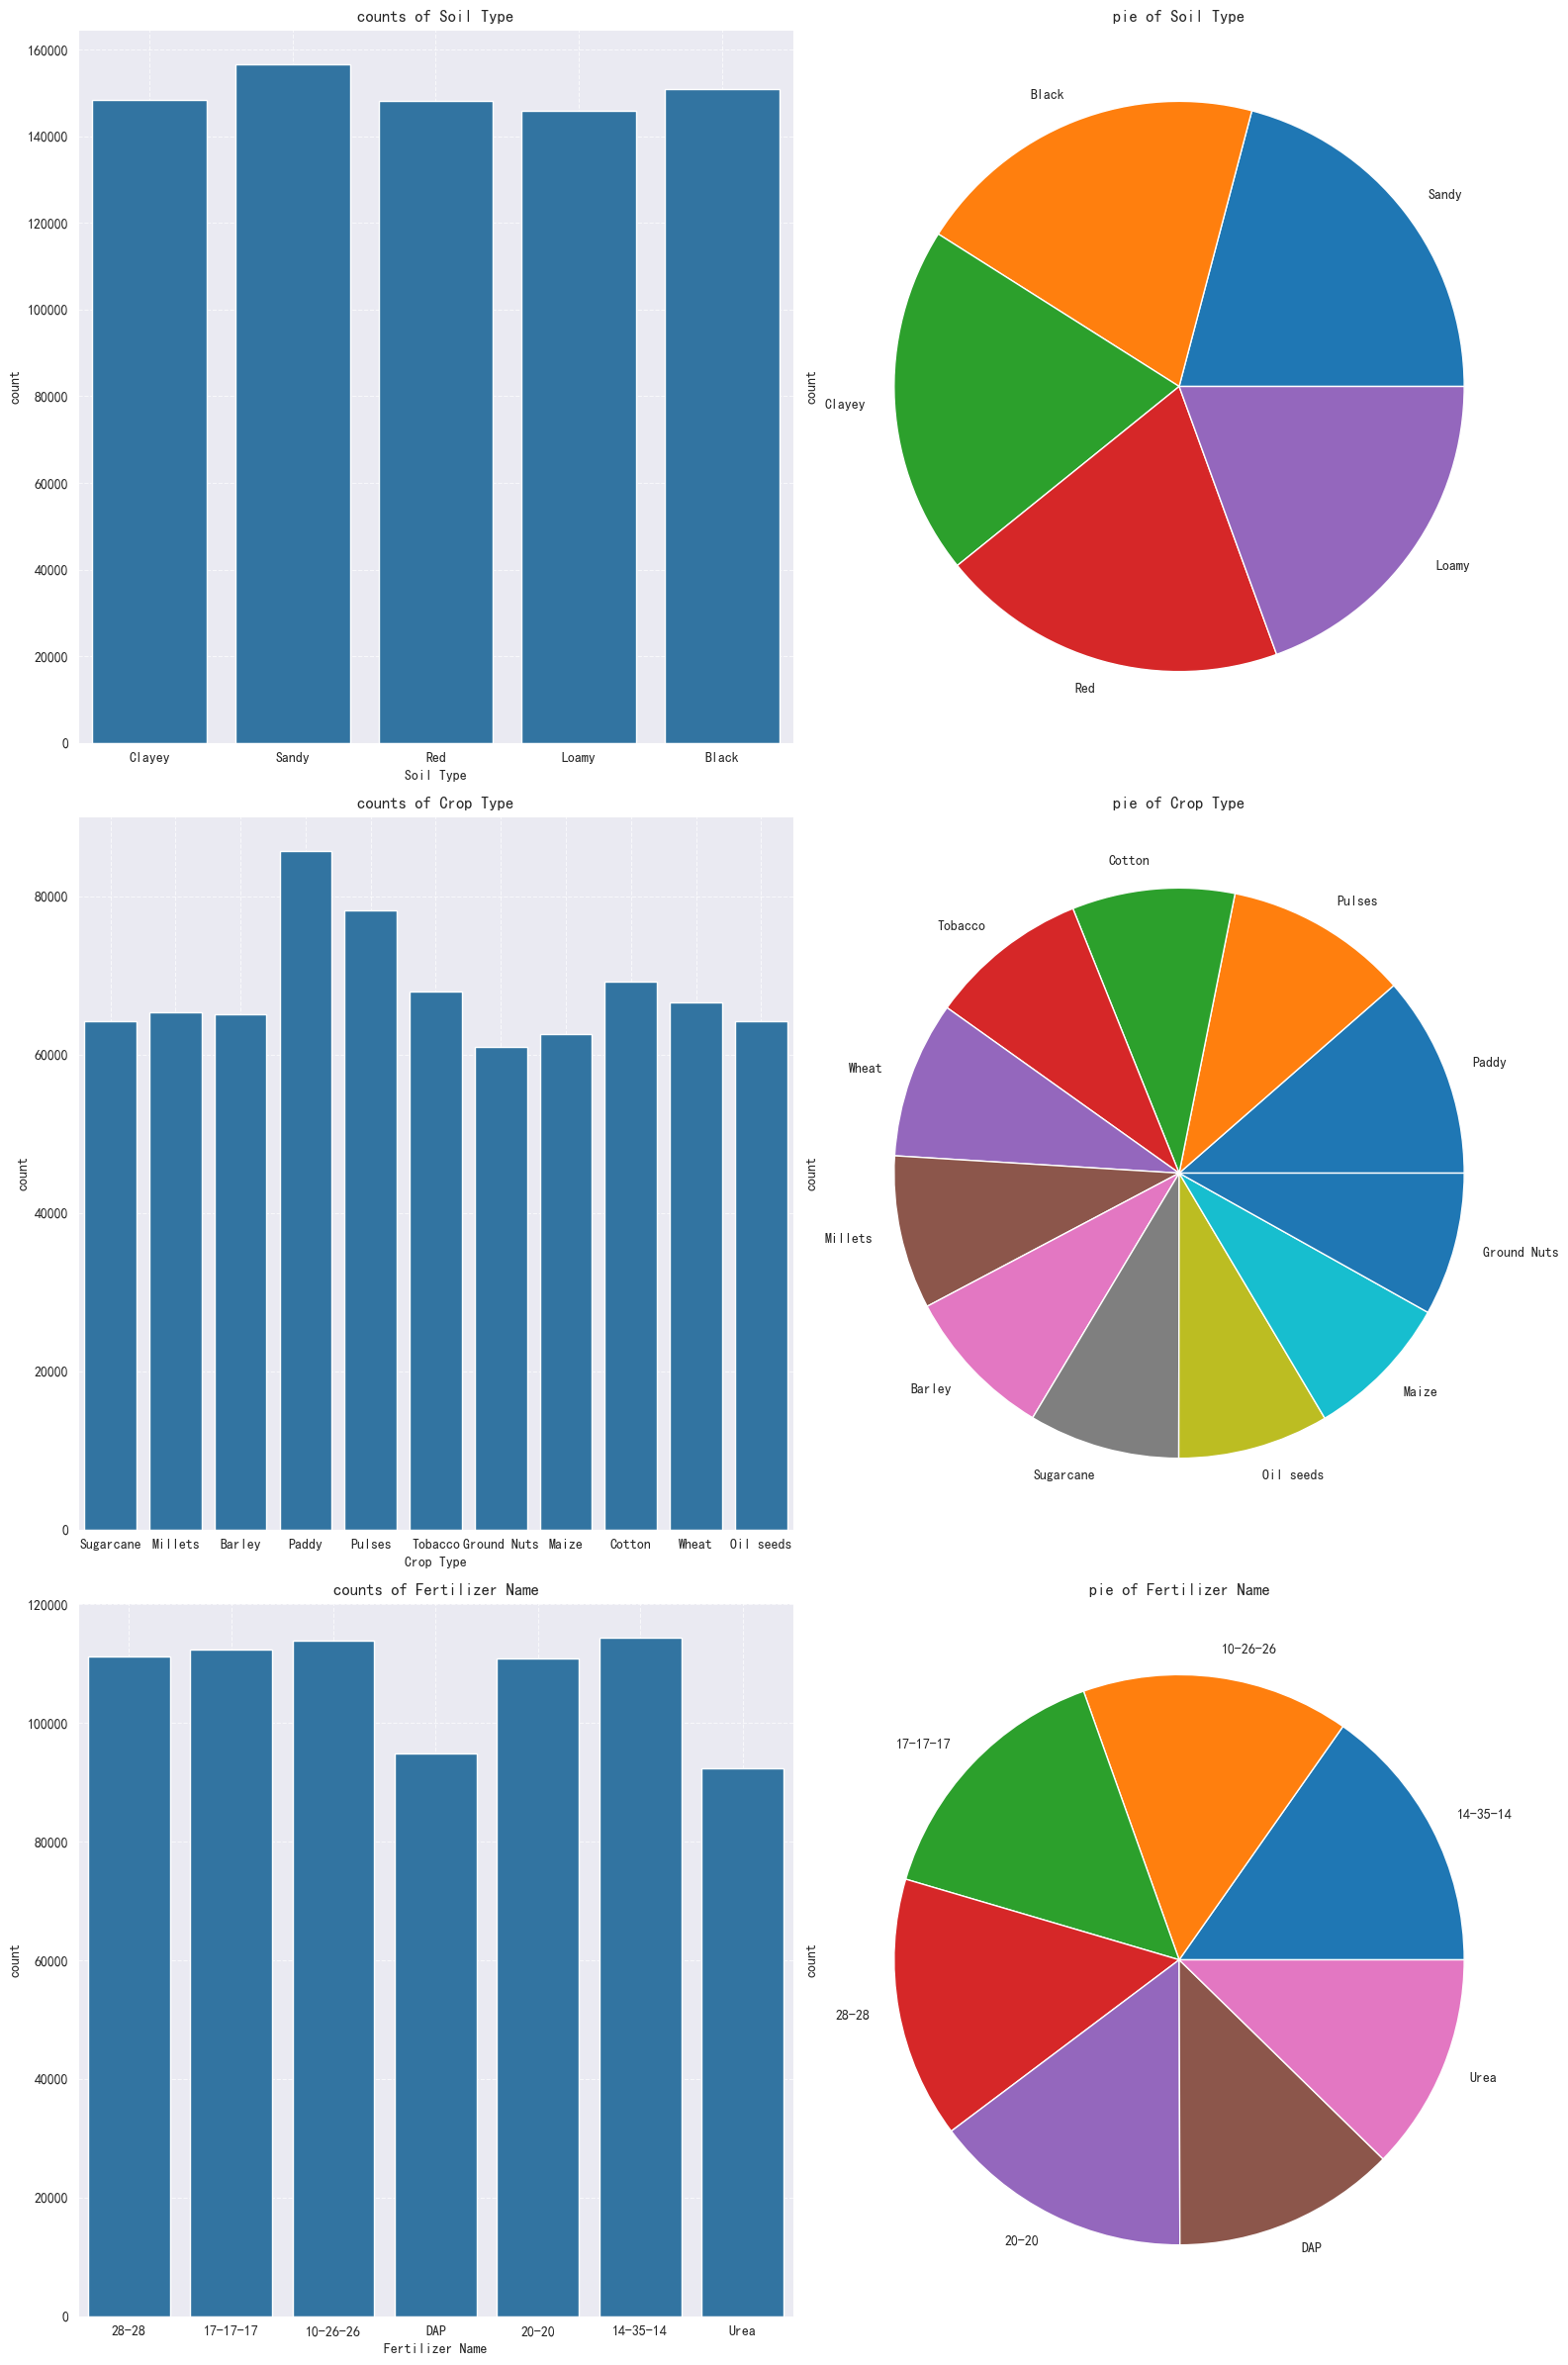

In [65]:
# cat_col 
fig, ax = plt.subplots(len(cat_col), 2, figsize=(16, 24))
for idx, col in enumerate(cat_col):
    # 柱形图
    sns.countplot(data=train_data, x=col, ax=ax[idx, 0])
    ax[idx, 0].set_title('counts of {}'.format(col))
    ax[idx, 0].grid(True, linestyle='--', alpha=0.7)
    # 饼图
    train_data[col].value_counts().plot(kind='pie', ax=ax[idx, 1])
    ax[idx, 1].set_title('pie of {}'.format(col))
plt.tight_layout()
plt.show()

In [66]:
# # 多变量分布
# fig, axes = plt.subplots(len(num_col), 3, figsize=(18, 35))
# for i, col in enumerate(num_col):
#     sns.kdeplot(data=train_data, x=col,fill=True, ax=axes[i, 0], 
#                  hue='Fertilizer Name')  
#     axes[i, 0].set_title(f'{col}分布图', fontsize=22)
#     axes[i, 0].grid(True, linestyle='--', alpha=0.7)
# 
#     sns.boxenplot(data=train_data, x=col, ax=axes[i, 1], 
#                   hue='Fertilizer Name') 
#     axes[i, 1].set_title(f'{col}箱线图', fontsize=22)
#     axes[i, 1].grid(True, linestyle='--', alpha=0.7)
# 
# 
#     sns.violinplot(data=train_data, x=col, ax=axes[i, 2], 
#                    hue='Fertilizer Name') 
#     # 添加小提琴图的标题
#     axes[i, 2].set_title(f'{col}小提琴图', fontsize=22)
#     axes[i, 2].grid(True, linestyle='--', alpha=0.7)
# 
# plt.tight_layout()
# plt.show()

In [67]:
train_data.columns

Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

In [68]:
# 特征工程
train_data['Temp_Humid'] = train_data['Temparature'] / train_data['Humidity'] + 1
test_data['Temp_Humid'] = test_data['Temparature'] / test_data['Humidity']

# 微量元素
train_data['sum_Ni_Po_Ph'] = train_data[['Nitrogen', 'Phosphorous', 'Potassium']].sum(axis=1)
test_data['sum_Ni_Po_Ph'] = test_data[['Nitrogen', 'Phosphorous', 'Potassium']].sum(axis=1)

train_data['N/P_ratio'] = train_data['Nitrogen'] / (train_data['Phosphorous'] + 1) 
test_data['N/P_ratio'] = test_data['Nitrogen'] / (test_data['Phosphorous'] + 1) 

train_data['N/K_ratio'] = train_data['Nitrogen'] / (train_data['Potassium'] + 1)
test_data['N/K_ratio'] = test_data['Nitrogen'] / (test_data['Potassium'] + 1)

train_data['K/P_ratio'] = train_data['Potassium'] / (train_data['Phosphorous'] + 1)
test_data['K/P_ratio'] = test_data['Potassium'] / (test_data['Phosphorous'] + 1)

train_data['NPK_balance'] = train_data['Nitrogen'] + train_data['Phosphorous'] - train_data['Potassium']  # 营养平衡值
test_data['NPK_balance'] = test_data['Nitrogen'] + test_data['Phosphorous'] - test_data['Potassium']

bins = [0, 30, 60, 100]
labels = ['Dry', 'Optimal', 'Wet']
train_data['Moisture_Level'] = pd.cut(train_data['Moisture'], bins=bins, labels=labels)
test_data['Moisture_Level'] = pd.cut(test_data['Moisture'], bins=bins, labels=labels)

In [69]:
train_data

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Temp_Humid,sum_Ni_Po_Ph,N/P_ratio,N/K_ratio,K/P_ratio,NPK_balance,Moisture_Level
0,37,70,36,Clayey,Sugarcane,36,4,5,28-28,1.528571,45,6.000000,7.200000,0.666667,37,Optimal
1,27,69,65,Sandy,Millets,30,6,18,28-28,1.391304,54,1.578947,4.285714,0.315789,42,Wet
2,29,63,32,Sandy,Millets,24,12,16,17-17-17,1.460317,52,1.411765,1.846154,0.705882,28,Optimal
3,35,62,54,Sandy,Barley,39,12,4,10-26-26,1.564516,55,7.800000,3.000000,2.400000,31,Optimal
4,35,58,43,Red,Paddy,37,2,16,DAP,1.603448,55,2.176471,12.333333,0.117647,51,Optimal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,25,69,30,Clayey,Maize,8,16,6,28-28,1.362319,30,1.142857,0.470588,2.285714,-2,Dry
749996,37,64,58,Loamy,Sugarcane,38,8,20,17-17-17,1.578125,66,1.809524,4.222222,0.380952,50,Optimal
749997,35,68,59,Sandy,Ground Nuts,6,11,29,10-26-26,1.514706,46,0.200000,0.500000,0.366667,24,Optimal
749998,31,68,29,Red,Cotton,9,11,12,20-20,1.455882,32,0.692308,0.750000,0.846154,10,Dry


In [70]:
test_data

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Temp_Humid,sum_Ni_Po_Ph,N/P_ratio,N/K_ratio,K/P_ratio,NPK_balance,Moisture_Level
0,31,70,52,Sandy,Wheat,34,11,24,0.442857,69,1.360000,2.833333,0.440000,47,Optimal
1,27,62,45,Red,Sugarcane,30,14,15,0.435484,59,1.875000,2.000000,0.875000,31,Optimal
2,28,72,28,Clayey,Ground Nuts,14,15,4,0.388889,33,2.800000,0.875000,3.000000,3,Dry
3,37,53,57,Black,Ground Nuts,18,17,36,0.698113,71,0.486486,1.000000,0.459459,37,Optimal
4,31,55,32,Red,Pulses,13,19,14,0.563636,46,0.866667,0.650000,1.266667,8,Optimal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,26,66,30,Red,Sugarcane,14,7,18,0.393939,39,0.736842,1.750000,0.368421,25,Dry
249996,33,62,55,Red,Pulses,28,14,7,0.532258,49,3.500000,1.866667,1.750000,21,Optimal
249997,36,53,64,Black,Paddy,28,11,27,0.679245,66,1.000000,2.333333,0.392857,44,Wet
249998,36,67,26,Clayey,Paddy,33,0,10,0.537313,43,3.000000,33.000000,0.000000,43,Dry


In [71]:
from sklearn.preprocessing import LabelEncoder
# 1. 将Moisture_Level转换为数值编码
moisture_map = {'Dry': 0, 'Optimal': 1, 'Wet': 2}
train_data['Moisture_Level'] = train_data['Moisture_Level'].map(moisture_map).astype(int)
test_data['Moisture_Level'] = test_data['Moisture_Level'].map(moisture_map).astype(int)

# 2. 使用同一个LabelEncoder对象处理分类特征
# 这样确保训练集和测试集的编码一致
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fertilizer = LabelEncoder()

# 先拟合训练集
train_data['Soil Type'] = le_soil.fit_transform(train_data['Soil Type'])
train_data['Crop Type'] = le_crop.fit_transform(train_data['Crop Type'])
train_data['Fertilizer Name'] = le_fertilizer.fit_transform(train_data['Fertilizer Name'])

# 然后用训练集的编码器转换测试集
test_data['Soil Type'] = le_soil.transform(test_data['Soil Type'])
test_data['Crop Type'] = le_crop.transform(test_data['Crop Type'])


In [72]:
# 3. 处理无穷值（K/P_ratio列中有inf）
# 将无穷值替换为列的最大值
for df in [train_data, test_data]:
    mask = df['K/P_ratio'] == float('inf')
    if mask.any():
        max_val = df.loc[~mask, 'K/P_ratio'].max()
        df.loc[mask, 'K/P_ratio'] = max_val if not pd.isna(max_val) else 0

In [73]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    enable_categorical=False 
)

xgb.fit(
    train_data.drop(columns=['Fertilizer Name']),
    train_data['Fertilizer Name']
)

# 5. 预测并转换回原始标签
pred = xgb.predict(test_data)
pred_labels = le_fertilizer.inverse_transform(pred)

In [74]:
pred_labels

array(['28-28', '17-17-17', '20-20', ..., '14-35-14', '14-35-14',
       '14-35-14'], dtype=object)

In [75]:
sample = pd.read_csv('sample_submission.csv')
submission = pd.DataFrame({
    'id': sample.id,
    'Fertilizer Name': pred_labels
})
submission.to_csv('submission.csv', index=False)